In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path().absolute().parent))

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

con = duckdb.connect("../data/processed/nba.duckdb")

df = con.execute("SELECT * FROM model_features").df()
print(f"Shape: {df.shape}")
print(f"Seasons: {df['SEASON'].min()} to {df['SEASON'].max()} ({df['SEASON'].nunique()} seasons)")
print(f"\nColumns ({len(df.columns)}):\n{df.columns.tolist()}")

focus_features = [
    'rs_net_rating',
    'rs_off_rating',
    'rs_def_rating',
    'rs_vs_top_teams_win_pct',
    'playoff_readiness_score',
]

print("\nFocus feature availability:")
print(df[focus_features].notna().sum().rename('non_null_rows').to_frame())

display(df.head(10))



Shape: (240, 51)
Seasons: 2010-11 to 2024-25 (15 seasons)

Columns (51):
['TEAM_ID', 'TEAM_ABBR', 'SEASON', 'games_played', 'playoff_games', 'foul_rate', 'foul_rate_playoff', 'foul_rate_delta', 'ft_rate', 'ft_rate_playoff', 'ft_rate_delta', 'dreb_pct', 'dreb_pct_playoff', 'dreb_pct_delta', 'physicality_score', 'three_pt_rate_delta', 'ts_pct_delta', 'efg_pct_delta', 'tov_rate_delta', 'blk_rate_delta', 'stl_rate_delta', 'ppg_delta', 'rs_close_game_win_pct', 'rs_close_game_count', 'playoff_rounds_reached', 'playoff_rounds_prior', 'offensive_adaptability_score', 'defensive_intensity_score', 'ball_security_score', 'po_games_played', 'rs_ppg', 'po_ppg', 'rs_off_rating', 'rs_def_rating', 'rs_net_rating', 'po_off_rating', 'po_def_rating', 'po_net_rating', 'off_rating_delta', 'def_rating_delta', 'net_rating_delta', 'rs_vs_top_teams_win_pct', 'rs_vs_top_teams_games', 'lineup_quality_score', 'depth_score', 'star_availability_rate', 'second_star_availability_rate', 'injury_games_lost', 'rotation_s

,TEAM_ID,TEAM_ABBR,SEASON,games_played,playoff_games,foul_rate,foul_rate_playoff,foul_rate_delta,ft_rate,ft_rate_playoff,...,rs_vs_top_teams_win_pct,rs_vs_top_teams_games,lineup_quality_score,depth_score,star_availability_rate,second_star_availability_rate,injury_games_lost,rotation_size,avg_availability_rate,playoff_readiness_score
0,1610612737,ATL,2010-11,82,12,24.171722,26.813187,2.641465,0.268782,0.289011,...,0.250000,24,0.922266,0.813661,1.000000,1.000000,7,7,0.916667,0.239979
1,1610612737,ATL,2011-12,66,6,22.026926,25.000000,2.973074,0.258975,0.203782,...,0.352941,17,0.930393,0.874012,1.000000,0.833333,4,8,0.916667,-1.267552
2,1610612737,ATL,2012-13,82,6,22.170379,31.250000,9.079621,0.243679,0.338362,...,0.333333,21,0.903573,0.737735,1.000000,1.000000,6,7,0.857143,0.550793
3,1610612737,ATL,2013-14,82,7,23.579545,26.497278,2.917732,0.266447,0.315789,...,0.272727,22,0.988105,0.952381,1.000000,1.000000,1,9,0.984127,0.319267
4,1610612737,ATL,2014-15,82,16,21.749515,23.009496,1.259981,0.258994,0.227173,...,0.714286,21,0.901102,0.790007,1.000000,0.875000,22,10,0.862500,-0.128966
5,1610612737,ATL,2015-16,82,10,22.678030,23.820755,1.142725,0.236603,0.241745,...,0.200000,15,0.926860,0.786823,1.000000,1.000000,11,10,0.890000,0.212230
6,1610612737,ATL,2016-17,82,6,21.552472,25.246548,3.694077,0.294738,0.343195,...,0.500000,20,0.988276,0.944444,1.000000,1.000000,1,9,0.981481,-0.210038
7,1610612737,ATL,2020-21,72,18,22.162076,24.455826,2.293750,0.277822,0.240717,...,0.352941,17,0.763251,0.662650,0.888889,1.000000,49,11,0.752525,0.012599
8,1610612737,ATL,2021-22,82,5,21.184919,27.621483,6.436564,0.252589,0.281330,...,0.500000,22,0.909156,0.797241,1.000000,1.000000,4,9,0.911111,-0.610658
9,1610612737,ATL,2022-23,82,6,20.345920,16.955017,-3.390903,0.244257,0.176471,...,0.333333,18,0.974536,0.941074,0.833333,1.000000,1,8,0.979167,-0.260820


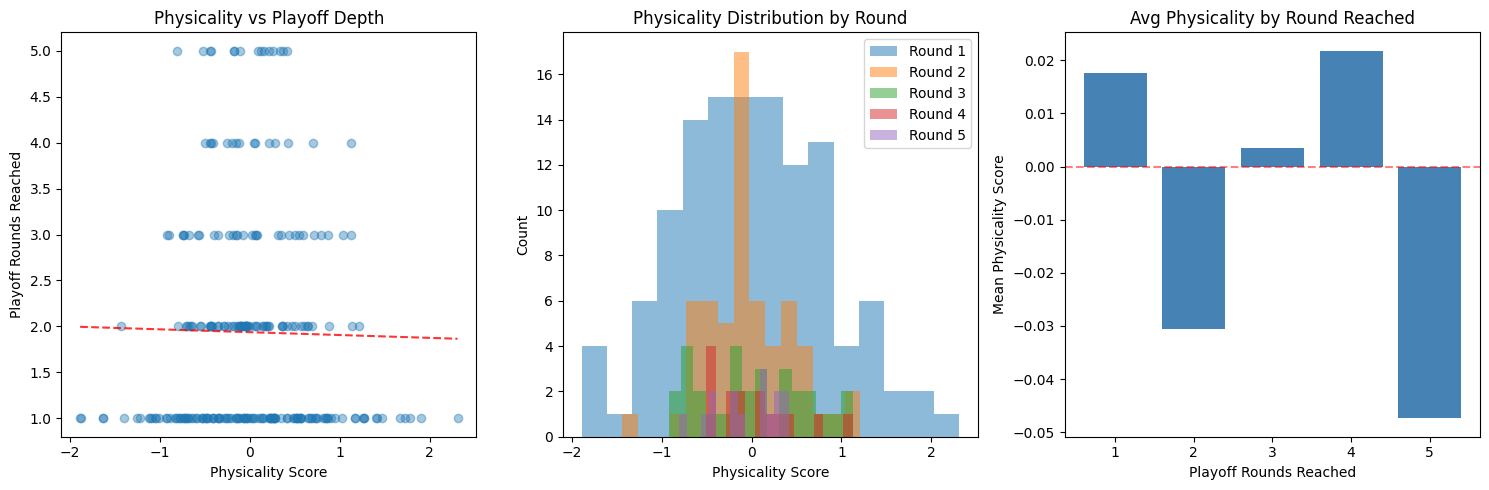

Correlation: physicality_score vs playoff_rounds_reached = -0.018


In [2]:
# Does physicality score predict playoff rounds reached?
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Physicality score vs rounds reached
axes[0].scatter(df['physicality_score'], df['playoff_rounds_reached'], alpha=0.4)
axes[0].set_xlabel('Physicality Score')
axes[0].set_ylabel('Playoff Rounds Reached')
axes[0].set_title('Physicality vs Playoff Depth')

# Add trend line
import numpy as np
z = np.polyfit(df['physicality_score'].fillna(0), df['playoff_rounds_reached'].fillna(0), 1)
p = np.poly1d(z)
x_line = np.linspace(df['physicality_score'].min(), df['physicality_score'].max(), 100)
axes[0].plot(x_line, p(x_line), 'r--', alpha=0.8)

# Plot 2: Distribution of physicality score by rounds reached
df_clean = df.dropna(subset=['physicality_score', 'playoff_rounds_reached'])
for rounds in sorted(df_clean['playoff_rounds_reached'].unique()):
    subset = df_clean[df_clean['playoff_rounds_reached'] == rounds]['physicality_score']
    axes[1].hist(subset, alpha=0.5, label=f'Round {int(rounds)}', bins=15)
axes[1].set_xlabel('Physicality Score')
axes[1].set_ylabel('Count')
axes[1].set_title('Physicality Distribution by Round')
axes[1].legend()

# Plot 3: Mean physicality score by rounds reached
mean_by_round = df_clean.groupby('playoff_rounds_reached')['physicality_score'].mean()
axes[2].bar(mean_by_round.index.astype(int), mean_by_round.values, color='steelblue')
axes[2].set_xlabel('Playoff Rounds Reached')
axes[2].set_ylabel('Mean Physicality Score')
axes[2].set_title('Avg Physicality by Round Reached')
axes[2].axhline(y=0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Correlation
corr = df_clean['physicality_score'].corr(df_clean['playoff_rounds_reached'])
print(f"Correlation: physicality_score vs playoff_rounds_reached = {corr:.3f}")

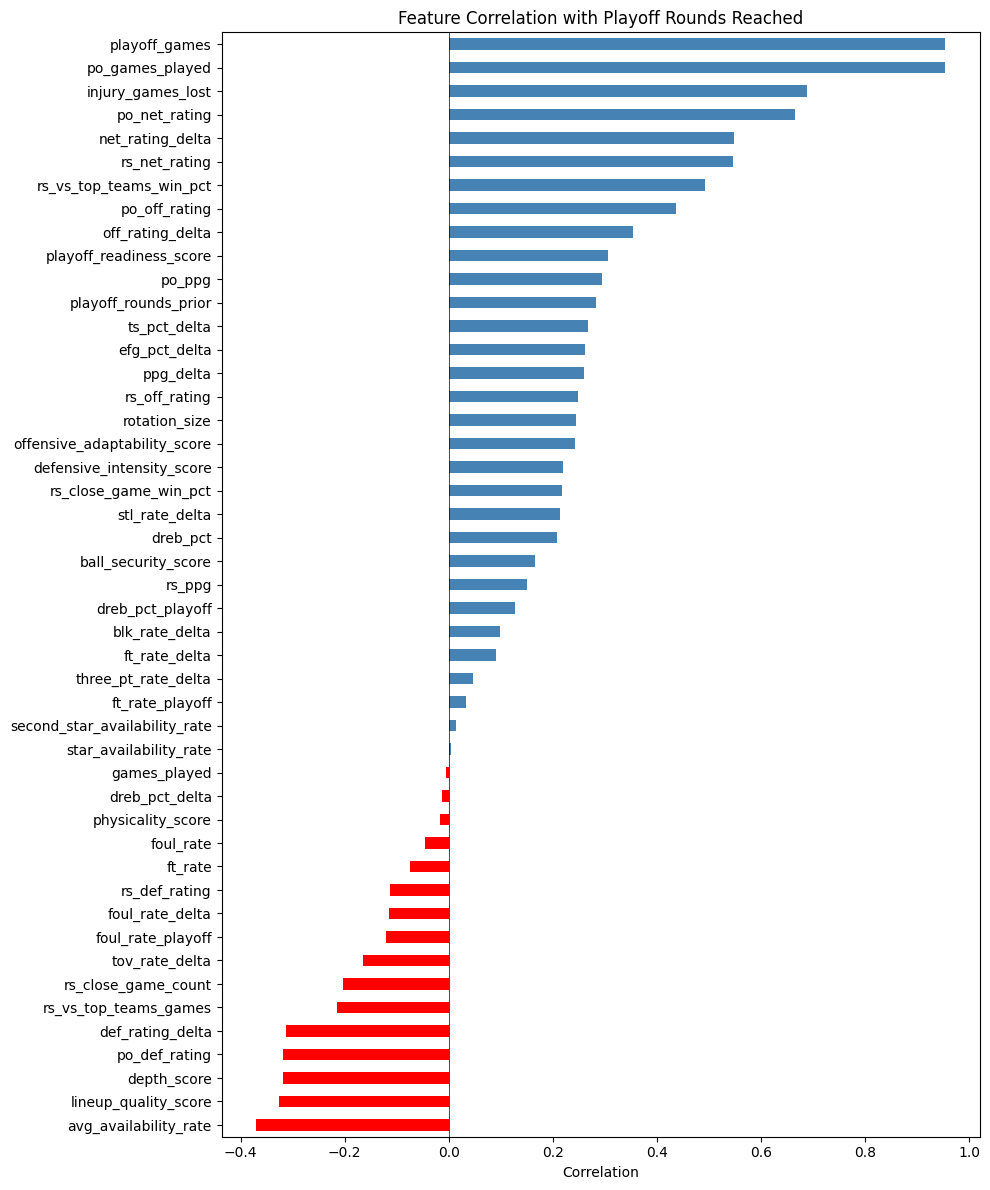


Top 5 positive correlations:
net_rating_delta     0.547140
po_net_rating        0.664793
injury_games_lost    0.688692
po_games_played      0.953655
playoff_games        0.953655
dtype: float64

Top 5 negative correlations:
avg_availability_rate   -0.370250
lineup_quality_score    -0.325573
depth_score             -0.319181
po_def_rating           -0.318288
def_rating_delta        -0.312589
dtype: float64


In [3]:
# Correlation of ALL features vs playoff rounds reached
numeric_cols = df.select_dtypes(include='number').columns.tolist()
exclude = ['TEAM_ID', 'playoff_rounds_reached']
feature_cols = [c for c in numeric_cols if c not in exclude]

correlations = df[feature_cols].corrwith(df['playoff_rounds_reached']).sort_values()

plt.figure(figsize=(10, 12))
correlations.plot(kind='barh', color=['red' if x < 0 else 'steelblue' for x in correlations])
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.title('Feature Correlation with Playoff Rounds Reached')
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()

print("\nTop 5 positive correlations:")
print(correlations.tail(5))
print("\nTop 5 negative correlations:")
print(correlations.head(5))

In [4]:
# Show actual calculated values for every feature for a few familiar teams
teams_to_show = ['LAL', 'GSW', 'SAS', 'MIA', 'BOS']

sample = df[df['TEAM_ABBR'].isin(teams_to_show)].sort_values(['TEAM_ABBR', 'SEASON'])

# Show one season per team for readability
latest = sample.groupby('TEAM_ABBR').last().reset_index()

# All numeric features
numeric_cols = df.select_dtypes(include='number').columns.tolist()
exclude = ['TEAM_ID']
feature_cols = ['TEAM_ABBR', 'SEASON'] + [c for c in numeric_cols if c not in exclude]

display(latest[feature_cols].T)

,0,1,2,3,4
TEAM_ABBR,BOS,GSW,LAL,MIA,SAS
SEASON,2024-25,2024-25,2024-25,2024-25,2018-19
games_played,82,82,82,82,82
playoff_games,11,12,5,4,7
foul_rate,17.651043,21.195359,20.194092,17.862146,20.516004
foul_rate_playoff,23.54874,24.756335,26.649746,21.165644,22.818792
foul_rate_delta,5.897697,3.560976,6.455655,3.303498,2.302788
ft_rate,0.212002,0.244334,0.271443,0.231718,0.237307
ft_rate_playoff,0.272727,0.239766,0.269036,0.162577,0.270134
ft_rate_delta,0.060725,-0.004567,-0.002407,-0.069141,0.032827


In [5]:
# Drop leakage columns and metadata
exclude = [
    'TEAM_ID', 'TEAM_ABBR', 'SEASON', 'playoff_games',
    'po_games_played', 'games_played', 'playoff_rounds_reached',
    'foul_rate_playoff', 'ft_rate_playoff', 'dreb_pct_playoff',
    'po_ppg', 'po_off_rating', 'po_def_rating', 'po_net_rating'
]

target = 'playoff_rounds_reached'
feature_cols = [
    c for c in df.select_dtypes(include='number').columns
    if c not in exclude + [target]
]

df_clean = df[feature_cols + [target]].dropna()

print(f"Features evaluated: {len(feature_cols)}")
print(f"Samples used: {len(df_clean)}")



Features evaluated: 37
Samples used: 240


In [6]:
# Correlation + statistical significance for every feature
results = []
for col in feature_cols:
    corr, pval = stats.pearsonr(df_clean[col], df_clean[target])
    results.append({
        'feature': col,
        'correlation': corr,
        'abs_correlation': abs(corr),
        'p_value': pval,
        'significant': pval < 0.05
    })

results_df = pd.DataFrame(results).sort_values('abs_correlation', ascending=False)

print("Feature correlations with rounds_reached (sorted by strength):\n")
print(results_df.to_string(index=False))

Feature correlations with rounds_reached (sorted by strength):

                      feature  correlation  abs_correlation      p_value  significant
            injury_games_lost     0.688692         0.688692 4.378116e-35         True
             net_rating_delta     0.547140         0.547140 3.843081e-20         True
                rs_net_rating     0.545261         0.545261 5.461822e-20         True
      rs_vs_top_teams_win_pct     0.491901         0.491901 4.997088e-16         True
        avg_availability_rate    -0.370250         0.370250 3.267088e-09         True
             off_rating_delta     0.353944         0.353944 1.718080e-08         True
         lineup_quality_score    -0.325573         0.325573 2.487251e-07         True
                  depth_score    -0.319181         0.319181 4.379563e-07         True
             def_rating_delta    -0.312589         0.312589 7.743411e-07         True
      playoff_readiness_score     0.305072         0.305072 1.458861e-06    

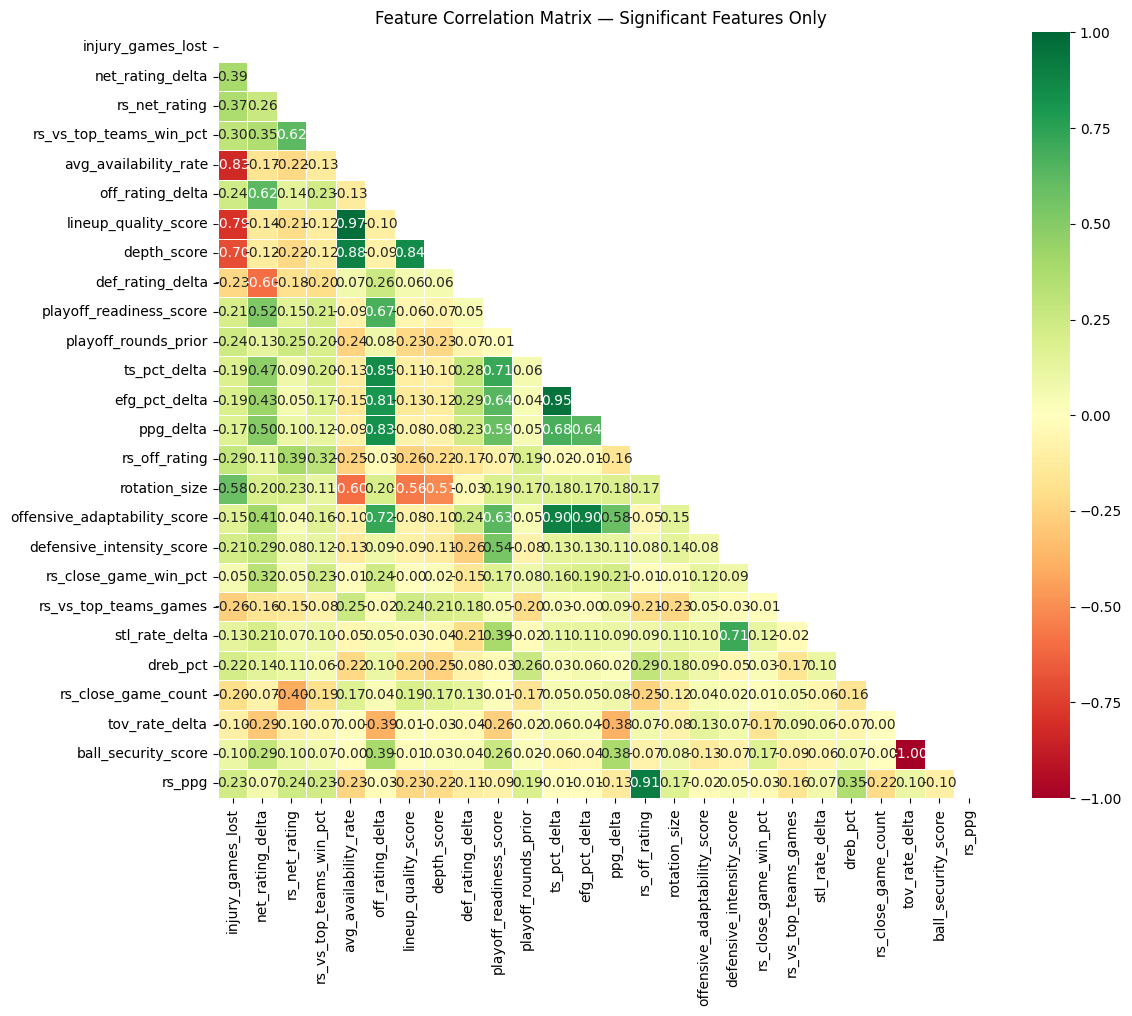


Highly correlated feature pairs (|r| > 0.7):
  injury_games_lost ↔ avg_availability_rate: -0.834
  injury_games_lost ↔ lineup_quality_score: -0.790
  avg_availability_rate ↔ lineup_quality_score: 0.974
  avg_availability_rate ↔ depth_score: 0.883
  off_rating_delta ↔ ts_pct_delta: 0.848
  off_rating_delta ↔ efg_pct_delta: 0.808
  off_rating_delta ↔ ppg_delta: 0.826
  off_rating_delta ↔ offensive_adaptability_score: 0.720
  lineup_quality_score ↔ depth_score: 0.845
  playoff_readiness_score ↔ ts_pct_delta: 0.711
  ts_pct_delta ↔ efg_pct_delta: 0.951
  ts_pct_delta ↔ offensive_adaptability_score: 0.898
  efg_pct_delta ↔ offensive_adaptability_score: 0.900
  rs_off_rating ↔ rs_ppg: 0.910
  defensive_intensity_score ↔ stl_rate_delta: 0.711
  tov_rate_delta ↔ ball_security_score: -1.000


In [7]:
# Multicollinearity check — which features are too correlated with each other?
significant_features = results_df[results_df['significant']]['feature'].tolist()

corr_matrix = df_clean[significant_features].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=0.5,
    vmin=-1, vmax=1
)
plt.title('Feature Correlation Matrix — Significant Features Only')
plt.tight_layout()
plt.show()

# Flag high correlation pairs
print("\nHighly correlated feature pairs (|r| > 0.7):")
for i in range(len(corr_matrix)):
    for j in range(i+1, len(corr_matrix)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.7:
            print(f"  {corr_matrix.index[i]} ↔ {corr_matrix.columns[j]}: {val:.3f}")

Missing from dataset: None


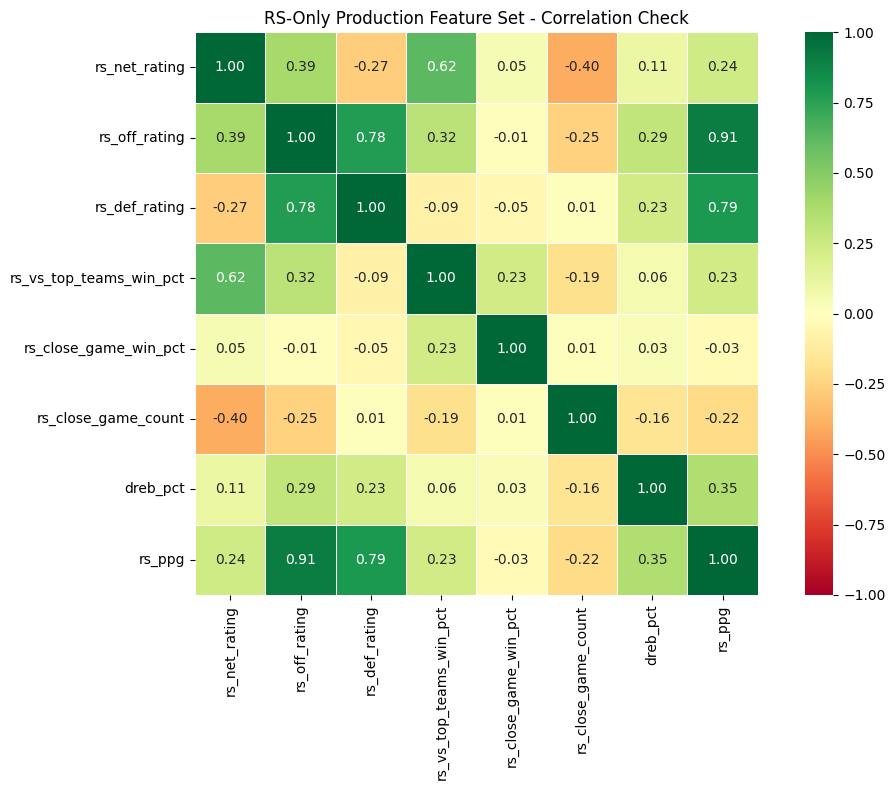

Max pairwise correlation (excluding diagonal):
  0.910

RS-only feature correlations with target:


,feature,correlation,abs_correlation,p_value
0,rs_net_rating,0.545261,0.545261,5.461822e-20
3,rs_vs_top_teams_win_pct,0.491901,0.491901,4.997088e-16
1,rs_off_rating,0.248129,0.248129,1.023907e-04
4,rs_close_game_win_pct,0.218228,0.218228,6.634657e-04
6,dreb_pct,0.208027,0.208027,1.189230e-03
5,rs_close_game_count,-0.202781,0.202781,1.588891e-03
7,rs_ppg,0.149901,0.149901,2.016457e-02
2,rs_def_rating,-0.112672,0.112672,8.151692e-02


In [8]:
final_features = [
    'rs_net_rating',
    'rs_off_rating',
    'rs_def_rating',
    'rs_vs_top_teams_win_pct',
    'rs_close_game_win_pct',
    'rs_close_game_count',
    'dreb_pct',
    'rs_ppg',
]

missing = [f for f in final_features if f not in df.columns]
print('Missing from dataset:', missing if missing else 'None')

final_corr = df_clean[final_features].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(
    final_corr,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=0.5,
    vmin=-1,
    vmax=1,
)
plt.title('RS-Only Production Feature Set - Correlation Check')
plt.tight_layout()
plt.show()

tmp = final_corr.copy()
np.fill_diagonal(tmp.values, 0)
print('Max pairwise correlation (excluding diagonal):')
print(f"  {tmp.abs().max().max():.3f}")

rows = []
for f in final_features:
    corr, pval = stats.pearsonr(df_clean[f], df_clean[target])
    rows.append({
        'feature': f,
        'correlation': corr,
        'abs_correlation': abs(corr),
        'p_value': pval,
    })

feature_target_df = pd.DataFrame(rows).sort_values('abs_correlation', ascending=False)
print('\nRS-only feature correlations with target:')
display(feature_target_df)



Feature health summary (RS-only model feature set):


,non_null,null_pct,mean,std,min,max
rs_net_rating,240,0.0,3.398479,2.840770,-2.990946,12.521244
rs_off_rating,240,0.0,108.819540,4.352548,98.866187,120.180970
rs_def_rating,240,0.0,105.421061,4.162221,95.654375,115.020298
rs_vs_top_teams_win_pct,240,0.0,0.430322,0.135910,0.062500,0.933333
rs_close_game_win_pct,240,0.0,0.556735,0.105961,0.250000,0.909091
rs_close_game_count,240,0.0,21.433333,4.548637,6.000000,39.000000
dreb_pct,240,0.0,0.763116,0.026025,0.691259,0.816905
rs_ppg,240,0.0,108.031591,7.268946,91.848485,123.292683


Season-level averages for ratings and top-team performance:


,SEASON,rs_net_rating,rs_off_rating,rs_def_rating,rs_vs_top_teams_win_pct
0,2010-11,3.670759,106.170377,102.499618,0.437235
1,2011-12,3.670261,103.465011,99.794750,0.436445
2,2012-13,3.538503,105.026997,101.488494,0.406381
3,2013-14,3.357921,105.535173,102.177252,0.437528
4,2014-15,3.323470,105.237424,101.913954,0.431739
5,2015-16,3.509677,105.816632,102.306955,0.355476
6,2016-17,2.800894,107.919780,105.118887,0.451361
7,2017-18,3.133142,108.071000,104.937858,0.439290
8,2018-19,3.416532,109.663324,106.246792,0.444742
9,2019-20,3.241323,109.573559,106.332237,0.443926


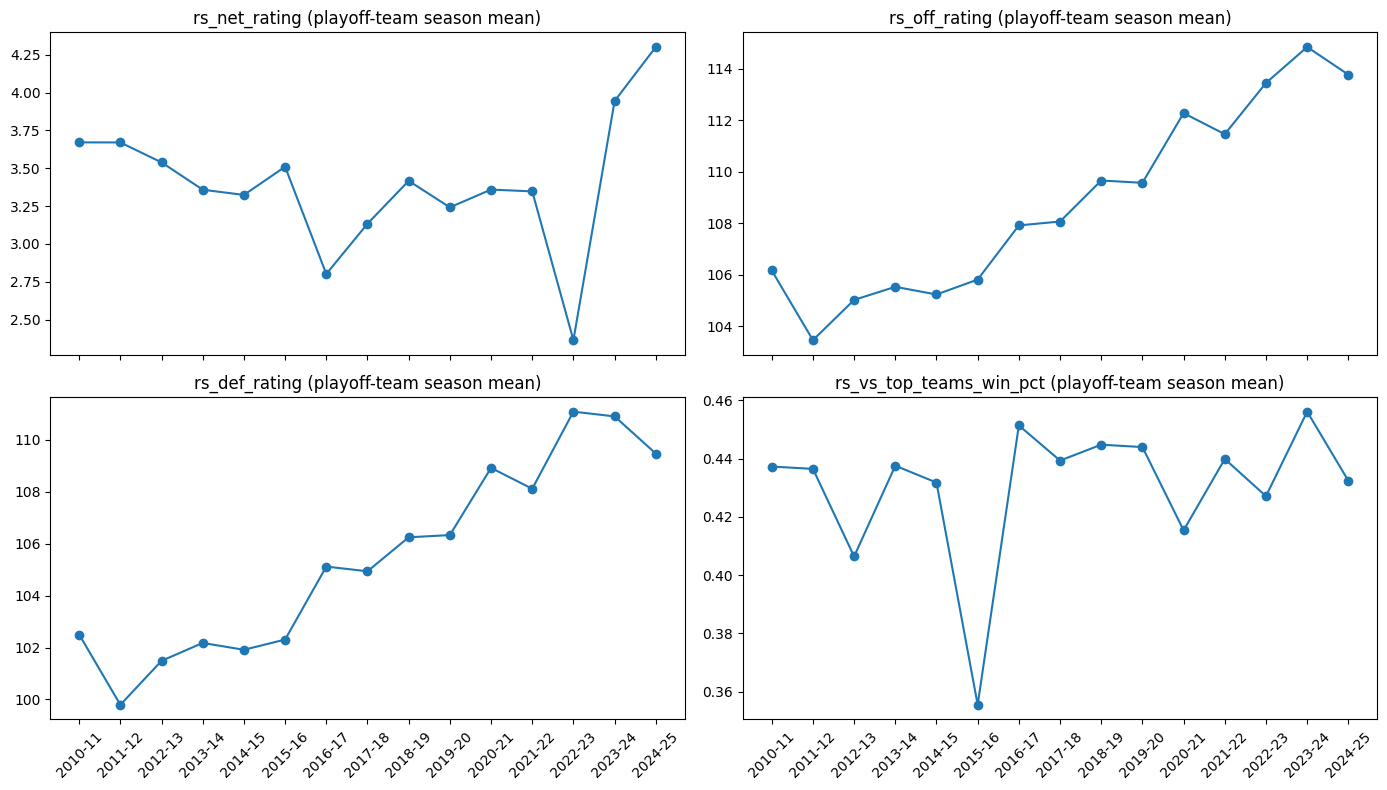

Availability shape: (240, 9)

Champions availability profile:
      SEASON team  rotation_size  avg_availability_rate  star_availability_rate  injury_games_lost
0    2024-25  OKC             12               0.818841                     1.0                 50
16   2023-24  BOS             10               0.815789                     1.0                 35
32   2022-23  DEN              8               0.975000                     1.0                  4
48   2021-22  GSW             12               0.727273                     1.0                 72
64   2020-21  MIL             10               0.817391                     1.0                 42
80   2019-20  LAL             10               0.909524                     1.0                 19
96   2018-19  TOR              9               0.884259                     1.0                 25
112  2017-18  GSW              8               0.827381                     1.0                 29
128  2016-17  GSW              9               

In [9]:
# Feature health summary for the RS-only production feature set
model_features = [
    'rs_net_rating',
    'rs_off_rating',
    'rs_def_rating',
    'rs_vs_top_teams_win_pct',
    'rs_close_game_win_pct',
    'rs_close_game_count',
    'dreb_pct',
    'rs_ppg',
]

feature_health = pd.DataFrame({
    'non_null': df[model_features].notna().sum(),
    'null_pct': df[model_features].isna().mean().round(4),
    'mean': df[model_features].mean(numeric_only=True),
    'std': df[model_features].std(numeric_only=True),
    'min': df[model_features].min(numeric_only=True),
    'max': df[model_features].max(numeric_only=True),
}).sort_values('null_pct', ascending=False)

print('Feature health summary (RS-only model feature set):')
display(feature_health)

new_features = ['rs_net_rating', 'rs_off_rating', 'rs_def_rating', 'rs_vs_top_teams_win_pct']
trend = (
    df.groupby('SEASON')[new_features]
      .mean()
      .reset_index()
      .sort_values('SEASON')
)

print('Season-level averages for ratings and top-team performance:')
display(trend)

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
for ax, feat in zip(axes.ravel(), new_features):
    ax.plot(trend['SEASON'], trend[feat], marker='o')
    ax.set_title(f'{feat} (playoff-team season mean)')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Availability profile kept for context
avail = con.execute(
    """
    SELECT
        a.SEASON,
        t.abbreviation AS team,
        a.rotation_size,
        a.avg_availability_rate,
        a.star_availability_rate,
        a.lineup_quality_score,
        a.depth_score,
        a.injury_games_lost,
        s.rounds_reached
    FROM availability_features a
    JOIN team_series_summary s
        ON a.TEAM_ID = s.team_id AND a.SEASON = s.season
    LEFT JOIN teams t
        ON a.TEAM_ID = t.id
    ORDER BY a.SEASON DESC, s.rounds_reached DESC
    """
).df()

print(f"Availability shape: {avail.shape}")
print("\nChampions availability profile:")
print(avail[avail['rounds_reached'] == 5][[
    'SEASON', 'team', 'rotation_size',
    'avg_availability_rate', 'star_availability_rate',
    'injury_games_lost'
]].to_string())

con.close()

